# Notebook 02 — One-Electron Integrals

**MOLEKUL | Phase 2**

---

A quantum chemistry calculation computes expectation values of operators.
The first operators we encounter — the building blocks of *every* electronic structure method —
are the one-electron operators: overlap, kinetic energy, and nuclear attraction.

Before we can diagonalise a Hamiltonian we need to evaluate these integrals over our basis
functions. This notebook shows:

1. Why Gaussian basis functions make integrals tractable.
2. The three one-electron matrices: **S** (overlap), **T** (kinetic), **V** (nuclear attraction).
3. The McMurchie-Davidson recurrence that MOLEKUL uses internally.
4. The Boys function — the key special function underlying nuclear-attraction and two-electron integrals.
5. How to build and inspect the matrices for real molecules.

## 1. Gaussian basis functions

A **primitive Cartesian Gaussian** centred at $\mathbf{A}$ with exponent $\alpha$ and
angular momentum $(l_x, l_y, l_z)$ is:

$$
g(\mathbf{r}; \alpha, \mathbf{A}) = N\, (x-A_x)^{l_x}(y-A_y)^{l_y}(z-A_z)^{l_z}
    \exp\!\left(-\alpha|\mathbf{r}-\mathbf{A}|^2\right)
$$

where $N$ is a normalisation constant and $L = l_x + l_y + l_z$ is the total angular momentum
($L=0$: s-type, $L=1$: p-type, $L=2$: d-type).

**Why Gaussians?** The **Gaussian product theorem** says the product of two Gaussians centred
at $\mathbf{A}$ and $\mathbf{B}$ is a single Gaussian centred at a point $\mathbf{P}$
between them. This collapses 6D integrals to products of 1D integrals:

$$
\langle g_1 | g_2 \rangle = S_x \cdot S_y \cdot S_z, \quad
S_x = \int_{-\infty}^{\infty} (x-A_x)^{l_{x1}} (x-B_x)^{l_{x2}}
    e^{-\alpha_1(x-A_x)^2} e^{-\alpha_2(x-B_x)^2}\,dx
$$

A **contracted Gaussian basis function** is a fixed linear combination of primitives:
$$\phi_\mu(\mathbf{r}) = \sum_k c_k g_k(\mathbf{r}; \alpha_k, \mathbf{A})$$
The coefficients $c_k$ are determined by fitting to Slater-type (exponential) orbitals.

In [1]:
# --- Make the MOLEKUL package importable -------------------------------
# Best practice: install once from the repo root with
#     pip install -e ".[notebooks]"
# The fallback below locates the in-repo src/ automatically, so the
# notebook also runs from a fresh clone that has not been installed yet,
# regardless of which directory Jupyter was started from.
try:
    import molekul  # noqa: F401
except ModuleNotFoundError:
    import sys, pathlib
    for _p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (_p / "src" / "molekul").is_dir():
            sys.path.insert(0, str(_p / "src"))
            break
    import molekul  # noqa: F401
# -----------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from molekul.atoms import Atom
from molekul.molecule import Molecule
from molekul.basis_sto3g import STO3G
from molekul.integrals import (
    build_overlap,
    build_kinetic,
    build_nuclear,
    _boys,
    overlap_primitive,
    kinetic_primitive,
)

print("Imports OK")

Imports OK


## 2. The Boys function

Nuclear attraction integrals (and later, two-electron repulsion integrals) require:

$$
F_n(x) = \int_0^1 t^{2n} e^{-x t^2}\,dt
$$

This is the **Boys function**. The special cases are:
- $F_0(x) = \frac{\sqrt{\pi}}{2\sqrt{x}}\,\text{erf}(\sqrt{x})$ (related to the error function)
- $F_n(0) = \frac{1}{2n+1}$ (the $x \to 0$ limit)

For $n > 0$ MOLEKUL uses upward recurrence once $F_0$ is known from `math.erf`,
and a Taylor series for small $x$ where the recurrence would be inaccurate.

Let us plot $F_n(x)$ for several orders:

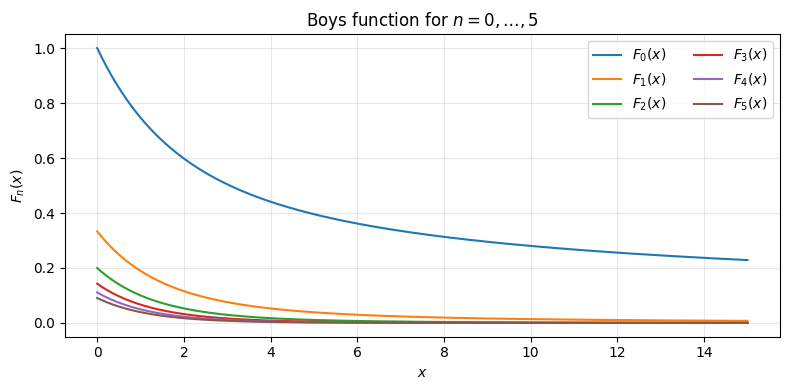

Limit check  F_n(1e-15):
  n=0: F_n(0) = 1.0000000000  exact = 1.0000000000  diff = 0.00e+00
  n=1: F_n(0) = 0.3333333333  exact = 0.3333333333  diff = 0.00e+00
  n=2: F_n(0) = 0.2000000000  exact = 0.2000000000  diff = 0.00e+00
  n=3: F_n(0) = 0.1428571429  exact = 0.1428571429  diff = 0.00e+00
  n=4: F_n(0) = 0.1111111111  exact = 0.1111111111  diff = 0.00e+00


In [2]:
x_vals = np.linspace(0, 15, 300)

fig, ax = plt.subplots(figsize=(8, 4))
for n in range(6):
    F = [_boys(n, x) for x in x_vals]
    ax.plot(x_vals, F, label=f"$F_{n}(x)$")

ax.set_xlabel("$x$")
ax.set_ylabel("$F_n(x)$")
ax.set_title("Boys function for $n = 0, \\ldots, 5$")
ax.legend(ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Verify the x->0 limit  F_n(0) = 1/(2n+1)
print("Limit check  F_n(1e-15):")
for n in range(5):
    val  = _boys(n, 1e-15)
    exact = 1.0 / (2 * n + 1)
    print(f"  n={n}: F_n(0) = {val:.10f}  exact = {exact:.10f}  diff = {abs(val-exact):.2e}")

## 3. McMurchie-Davidson recurrence

The McMurchie-Davidson scheme (1978) expresses products of Hermite Gaussians through
coefficients $E^{ij}_t$ that satisfy a three-term recurrence:

$$
E^{i+1,j}_t = \frac{1}{2p}E^{i,j}_{t-1} + X_{PA}\,E^{i,j}_t + (t+1)\,E^{i,j}_{t+1}
$$

where $p = \alpha_1 + \alpha_2$ and $X_{PA} = P_x - A_x = -\alpha_2 Q_x / p$,
$Q_x = A_x - B_x$.

The boundary condition is $E^{0,0}_0 = e^{-\alpha_1 \alpha_2 Q_x^2 / p}$
(the Gaussian product theorem factor).

The 1D overlap integral is then simply:
$$S_x(i,j) = \sqrt{\frac{\pi}{p}}\,E^{ij}_0$$

MOLEKUL memoises `_E(i, j, t, Qx, a, b)` with `@lru_cache` since the same coefficients
are reused across many integral pairs.

## 4. Building the integral matrices for H₂

We start with the simplest molecule: H₂ in STO-3G, which has two basis functions
(one 1s contracted Gaussian per atom). All three matrices are 2×2.

In [3]:
# H2 at experimental bond length 0.74 Angstrom
h2 = Molecule(
    atoms=[
        Atom.from_angstrom("H", 0.0, 0.0,  0.37),
        Atom.from_angstrom("H", 0.0, 0.0, -0.37),
    ],
    name="H2",
)

basis = STO3G
bfs   = basis.basis_functions(h2)
print(f"Basis functions: {len(bfs)}")
for i, (atom_idx, lx, ly, lz, shell) in enumerate(bfs):
    print(f"  BF {i}: atom {atom_idx} ({h2.atoms[atom_idx].symbol}), "
          f"l=({lx},{ly},{lz}), n_primitives={len(shell.exponents)}")

Basis functions: 2
  BF 0: atom 0 (H), l=(0,0,0), n_primitives=3
  BF 1: atom 1 (H), l=(0,0,0), n_primitives=3


In [4]:
S = build_overlap(basis, h2)
T = build_kinetic(basis, h2)
V = build_nuclear(basis, h2)
H_core = T + V

print("Overlap S:")
print(np.array2string(S, precision=6))

print("\nKinetic T:")
print(np.array2string(T, precision=6))

print("\nNuclear attraction V:")
print(np.array2string(V, precision=6))

print("\nCore Hamiltonian H = T + V:")
print(np.array2string(H_core, precision=6))

Overlap S:
[[1.       0.659873]
 [0.659873 1.      ]]

Kinetic T:
[[0.760032 0.23696 ]
 [0.23696  0.760032]]

Nuclear attraction V:
[[-1.880991 -1.196336]
 [-1.196336 -1.880991]]

Core Hamiltonian H = T + V:
[[-1.120959 -0.959376]
 [-0.959376 -1.120959]]


### Interpreting the overlap matrix

The diagonal of **S** is always 1 — each basis function is normalised.

The off-diagonal element $S_{12}$ measures how much the two 1s functions overlap.
For H₂ at 0.74 Å it is around 0.66 — the two atoms are close enough that their
electron clouds interpenetrate substantially.

If we stretched H₂ to large separation, $S_{12}$ would approach 0.  
At the united-atom limit (zero separation) it would approach 1.

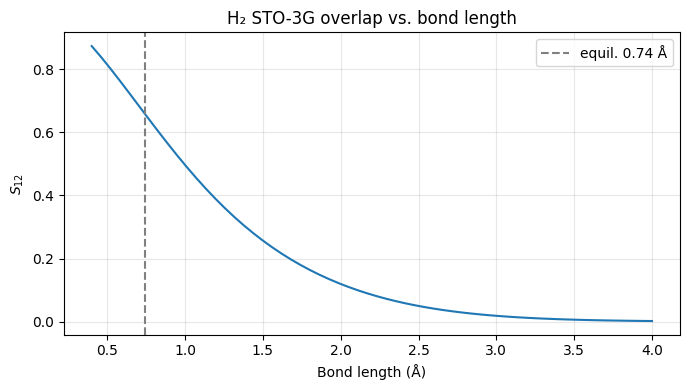

In [5]:
bond_lengths = np.linspace(0.4, 4.0, 60)  # Angstrom
S12 = []
for r in bond_lengths:
    mol = Molecule(
        atoms=[
            Atom.from_angstrom("H", 0.0, 0.0,  r/2),
            Atom.from_angstrom("H", 0.0, 0.0, -r/2),
        ]
    )
    Sm = build_overlap(STO3G, mol)
    S12.append(Sm[0, 1])

plt.figure(figsize=(7, 4))
plt.plot(bond_lengths, S12)
plt.axvline(0.74, ls="--", color="gray", label="equil. 0.74 Å")
plt.xlabel("Bond length (Å)")
plt.ylabel("$S_{12}$")
plt.title("H₂ STO-3G overlap vs. bond length")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Water in STO-3G: a 7×7 system

Water has O (1s, 2s, 2px, 2py, 2pz) + H + H (one 1s each) = 7 basis functions in STO-3G.

In [6]:
h2o = Molecule(
    atoms=[
        Atom.from_angstrom("O",  0.0000,  0.0000,  0.1173),
        Atom.from_angstrom("H",  0.7572,  0.0000, -0.4692),
        Atom.from_angstrom("H", -0.7572,  0.0000, -0.4692),
    ],
    name="water",
)

basis = STO3G
S_h2o = build_overlap(basis, h2o)
T_h2o = build_kinetic(basis, h2o)
V_h2o = build_nuclear(basis, h2o)

print(f"Matrix dimension: {S_h2o.shape}")
print(f"Diagonal of S (should all be 1.0): {np.diag(S_h2o).round(6)}")

Matrix dimension: (7, 7)
Diagonal of S (should all be 1.0): [1. 1. 1. 1. 1. 1. 1.]


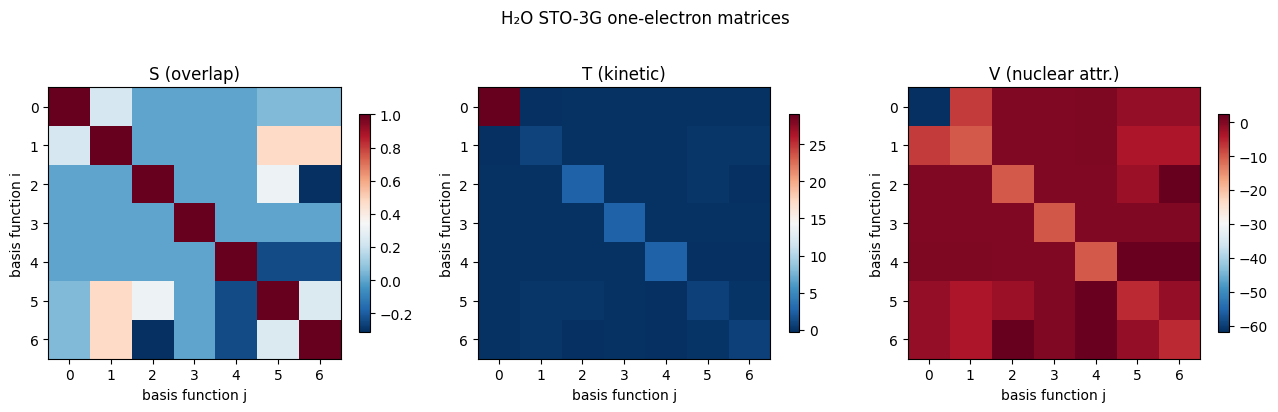

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
mats = [(S_h2o, "S (overlap)"), (T_h2o, "T (kinetic)"), (V_h2o, "V (nuclear attr.)")]
for ax, (M, title) in zip(axes, mats):
    im = ax.imshow(M, cmap="RdBu_r", aspect="auto")
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title)
    ax.set_xlabel("basis function j")
    ax.set_ylabel("basis function i")
plt.suptitle("H₂O STO-3G one-electron matrices", y=1.02)
plt.tight_layout()
plt.show()

## 6. Symmetry of the matrices

All three matrices must be **real and symmetric** — a necessary condition for
real Hermitian operators with real basis functions.

MOLEKUL exploits this by only computing the upper triangle and copying to the lower:
`if j < i: S[i, j] = S[j, i]`.
This halves the compute cost.

In [8]:
for M, name in [(S_h2o, "S"), (T_h2o, "T"), (V_h2o, "V")]:
    sym_err = np.max(np.abs(M - M.T))
    print(f"|{name} - {name}^T|_max = {sym_err:.2e}")

|S - S^T|_max = 0.00e+00
|T - T^T|_max = 0.00e+00
|V - V^T|_max = 0.00e+00


## 7. Eigenvalue structure

We cannot use **S** directly as an identity matrix — the basis functions are not
orthogonal. The smallest eigenvalue of **S** measures the degree of linear dependence;
if it is near zero, the basis is nearly redundant.

The kinetic energy matrix **T** is positive definite — all eigenvalues must be positive
(kinetic energy is always non-negative).

The nuclear attraction matrix **V** is negative definite — electrons are always
attracted to the nuclei.

In [9]:
evals_S = np.linalg.eigvalsh(S_h2o)
evals_T = np.linalg.eigvalsh(T_h2o)
evals_V = np.linalg.eigvalsh(V_h2o)

print("Eigenvalues of S:", np.round(evals_S, 4))
print("  min =", evals_S.min(), "  (all > 0 → no linear dependence)")
print()
print("Eigenvalues of T:", np.round(evals_T, 4))
print("  all positive:", (evals_T > 0).all())
print()
print("Eigenvalues of V:", np.round(evals_V, 4))
print("  all negative:", (evals_V < 0).all())

Eigenvalues of S: [0.3426 0.4169 0.8857 1.     1.093  1.3315 1.9302]
  min = 0.34258665720333237   (all > 0 → no linear dependence)

Eigenvalues of T: [ 0.5874  0.6966  0.9541  2.5287  2.5628  2.5837 29.0042]
  all positive: True

Eigenvalues of V: [-62.9643 -14.1795 -11.5302  -9.9859  -9.6797  -2.8312  -2.5712]
  all negative: True


## 8. Comparison with PySCF

Let us verify our integrals against PySCF's reference values for H₂O/STO-3G.
*(Skip this cell if PySCF is not installed.)*

In [10]:
try:
    from pyscf import gto, scf
    mol_pyscf = gto.Mole()
    mol_pyscf.atom = """
    O  0.0000  0.0000  0.1173
    H  0.7572  0.0000 -0.4692
    H -0.7572  0.0000 -0.4692
    """
    mol_pyscf.basis = "sto-3g"
    mol_pyscf.unit = "angstrom"
    mol_pyscf.build(verbose=0)

    S_ref = mol_pyscf.intor("int1e_ovlp")
    T_ref = mol_pyscf.intor("int1e_kin")
    V_ref = mol_pyscf.intor("int1e_nuc")

    print("Max |S - S_ref|:", np.max(np.abs(S_h2o - S_ref)))
    print("Max |T - T_ref|:", np.max(np.abs(T_h2o - T_ref)))
    print("Max |V - V_ref|:", np.max(np.abs(V_h2o - V_ref)))
except ImportError:
    print("PySCF not installed — skipping comparison.")

Max |S - S_ref|: 4.43366831026637e-08
Max |T - T_ref|: 3.087900960707657e-06
Max |V - V_ref|: 3.242563039407287e-06


## 9. Computational scaling

Building **S**, **T**, **V** all scale as $\mathcal{O}(N^2)$ in the number of basis
functions $N$ (plus a constant factor from the number of primitives per shell).

This is already the most expensive step per iteration for very small molecules,
but it is quickly dominated by the four-centre two-electron integrals (**ERI**),
which scale as $\mathcal{O}(N^4)$ — the subject of a later notebook.

For reference (MOLEKUL uses **6 Cartesian** functions per d-shell, so
d-containing counts run larger than the spherical-harmonic numbers some
textbooks quote):

| Molecule | STO-3G $N$ | cc-pVDZ $N$ |
|----------|-----------|------------|
| H₂       | 2         | 10         |
| H₂O      | 7         | 25         |
| N₂       | 10        | 30         |
| CH₄      | 9         | 35         |

In [11]:
# Quick sanity check with N2/STO-3G
from molekul.constants import HARTREE_TO_EV

n2 = Molecule(
    atoms=[
        Atom.from_angstrom("N", 0.0, 0.0,  0.549),
        Atom.from_angstrom("N", 0.0, 0.0, -0.549),
    ],
    name="N2",
)
basis = STO3G
S_n2 = build_overlap(basis, n2)
T_n2 = build_kinetic(basis, n2)
V_n2 = build_nuclear(basis, n2)
print(f"N2/STO-3G: {S_n2.shape[0]} basis functions")
print(f"sum(T diag) = {np.trace(T_n2):.4f} Ha  (rough kinetic KE estimate)")

N2/STO-3G: 10 basis functions
sum(T diag) = 56.5916 Ha  (rough kinetic KE estimate)


---

## Exercises

**1.** Evaluate the Boys function $F_0(x)$ analytically using `math.erf` and compare it to
the MOLEKUL implementation for $x \in \{0.01, 0.1, 1, 5, 20\}$.  
At what value of $x$ does the Taylor-series branch switch to the erf branch?

**2.** The diagonal of **T** gives the mean kinetic energy carried by each basis function.
For H₂O/STO-3G, which basis function has the highest kinetic energy? Why?
(Hint: compare the exponents of the s-type functions on O versus H.)

**3.** Compute **S**, **T**, **V** for HeH⁺ (He at origin, H at 0.7743 Å) in STO-3G.  
Verify that $S_{11} = S_{22} = 1$.

**4.** Write a function that takes the overlap matrix **S** and checks for linear dependence
by flagging any eigenvalue below a threshold (e.g., $10^{-6}$). Test it on H₂ stretched
to 10 Å — does near-degeneracy appear?

**5.** (Advanced) The nuclear attraction matrix $V_{ij} = \sum_C -Z_C\langle\phi_i|1/|\mathbf{r}-\mathbf{R}_C||\phi_j\rangle$.
For water, split $\mathbf{V}$ into its O-contribution and two H-contributions.  
Which nucleus contributes the most to the depth of the off-diagonal elements?  
What does this tell you about where electrons spend most of their time?

---

## Summary

| Matrix | Formula | Properties |
|--------|---------|------------|
| **S** (overlap) | $S_{ij} = \langle\phi_i|\phi_j\rangle$ | symmetric, positive definite, diagonal = 1 |
| **T** (kinetic) | $T_{ij} = \langle\phi_i|-\tfrac{1}{2}\nabla^2|\phi_j\rangle$ | symmetric, positive definite |
| **V** (nuclear) | $V_{ij} = \langle\phi_i|\sum_C -Z_C/r_C|\phi_j\rangle$ | symmetric, negative definite |
| **H** (core) | $H = T + V$ | symmetric; eigenvalues are one-electron energies in absence of e–e repulsion |

Key algorithmic ideas:
- **Gaussian product theorem** → 6D integrals factorise into 1D pieces.
- **McMurchie-Davidson** `_E(i, j, t)` → closed-form 1D overlap components, memoised.
- **Boys function** $F_n(x)$ → Taylor series for small $x$, erf + recurrence for large $x$.
- **Upper-triangle symmetry** → half the matrix elements computed.

In the next notebook we introduce the Gaussian basis sets themselves — how STO-3G,
6-31G\*, and cc-pVDZ are constructed, and what each additional set of functions buys you.